##### Contexto

Nuestro equipo de especialistas en ciencias del comportamiento ha trabajado con un cliente codo con codo para aumentar la proporción de usuarios finales que abren un email y pinchan en un banner dentro del email.
Han probado distintos tratamientos y nos han devuelto los datos. Ahora tenemos que analizar dichos datos y explicárselos al cliente creando un data storytelling que sea adecuado para que el cliente entienda a la perfección nuestro análisis y los resultados obtenidos.


##### Importe de librerías

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Carga de datos

In [7]:
df = pd.read_csv("/Users/david/BeWay/Centro de Excelencia - Datos/Bases de datos/datos_prueba_tecnica.csv", encoding='latin-1', sep=',')

### Exploratory Data Anlysis (EDA)

##### Inspección de los datos

In [10]:
# Check column data types and non-missing values
print("Column data types and non-missing values:")
print(df.info())

# Print the first five rows of the DataFrame
print("\n First five rows of the DataFrame:")
print(df.head())

# Print the last five rows of the DataFrame
print("\n Last five rows of the DataFrame:")
print(df.tail())

# Print the statistics of all columns
print("\n Statistics of all columns:")
print(df.describe())

Column data types and non-missing values:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   iid             5000 non-null   int64  
 1   grupo           5000 non-null   str    
 2   or              5000 non-null   int64  
 3   ctor            5000 non-null   int64  
 4   sexo            5000 non-null   int64  
 5   edad            5000 non-null   float64
 6   inve            5000 non-null   float64
 7   uso_app         5000 non-null   int64  
 8   tarjeta_debito  5000 non-null   int64  
 9   tipo_tarjeta    5000 non-null   int64  
 10  formacion       5000 non-null   int64  
dtypes: float64(2), int64(8), str(1)
memory usage: 429.8 KB
None

 First five rows of the DataFrame:
   iid  grupo  or  ctor  sexo       edad         inve  uso_app  \
0    1   ctrl   0     0     0  38.296148  51019.88612        1   
1    2  trat1   1     1     1  54.470670  63

##### Limpieza y procesamiento de datos

In [26]:
# Convertir id a string
df['iid'] = df['iid'].astype(str)

# Convertir edad a entero
df['edad'] = df['edad'].astype(int)

# Convertir cols a categoría
catcols = ['grupo', 'or', 'ctor', 'sexo', 'uso_app', 'tarjeta_debito', 'tipo_tarjeta', 'formacion']
df[catcols] = df[catcols].astype('category')

# Reconfirmar na's
print("Valores perdidos por columnas:")
print(df.isna().sum())

# Check column data types and non-missing values
print("\n Column data types and non-missing values:")
print(df.info())

# Print the first five rows of the DataFrame
print("\n First five rows of the DataFrame:")
print(df.head())

# Print the last five rows of the DataFrame
print("\n Last five rows of the DataFrame:")
print(df.tail())

# Print the statistics of all columns
print("\n Statistics of all columns:")
print(df.describe())

Valores perdidos por columnas:
iid               0
grupo             0
or                0
ctor              0
sexo              0
edad              0
inve              0
uso_app           0
tarjeta_debito    0
tipo_tarjeta      0
formacion         0
dtype: int64

 Column data types and non-missing values:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   iid             5000 non-null   str     
 1   grupo           5000 non-null   category
 2   or              5000 non-null   category
 3   ctor            5000 non-null   category
 4   sexo            5000 non-null   category
 5   edad            5000 non-null   int64   
 6   inve            5000 non-null   float64 
 7   uso_app         5000 non-null   category
 8   tarjeta_debito  5000 non-null   category
 9   tipo_tarjeta    5000 non-null   category
 10  formacion       5000 non-null   categor

##### Exploración por variables

In [25]:
# Análisis de id
print("\n Análisis iid")
print(f"Número de valores únicos (IDs): {df['iid'].nunique()}")


 Análisis iid
Número de valores únicos (IDs): 5000



--- Estadísticas Numéricas ---
Estadísticas de edad:
 count    5000.000000
mean       46.761000
std        11.152881
min        18.000000
25%        39.000000
50%        47.000000
75%        54.000000
max        70.000000
Name: edad, dtype: float64

Estadísticas de inversión (inve):
 count     5000.000000
mean     49477.863491
std      10913.533755
min      20689.644810
25%      41616.960403
50%      48159.059205
75%      57818.409473
max      82603.697460
Name: inve, dtype: float64


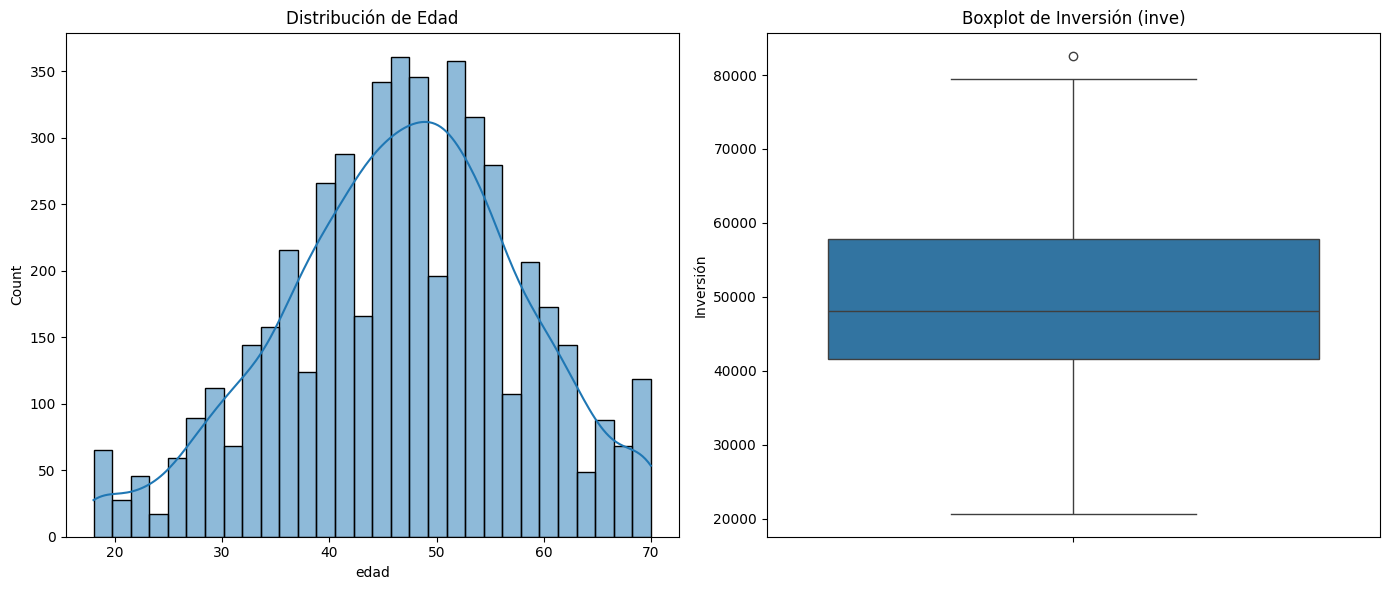

In [ ]:
# Análisis edad e inversión 
# Medidas de tendencia central, dispersión y distribución para variables numéricas
print("\n--- Estadísticas Numéricas ---")
print("Estadísticas de edad:\n", df['edad'].describe())
print("\nEstadísticas de inversión (inve):\n", df['inve'].describe())

# Graficación de distribución y boxplot para edad e inversión
# Canvas
plt.figure(figsize=(14, 6))

# Histograma y KDE para edad (distribución)
plt.subplot(1, 2, 1)
sns.histplot(df['edad'], kde=True)
plt.title('Distribución de Edad')

# Boxplot para outliers (Visualización de rango y posibles valores extremos)
plt.subplot(1, 2, 2)
sns.boxplot(y=df['inve'])
plt.title('Boxplot de Inversión (inve)')
plt.ylabel('Inversión')

plt.tight_layout()
plt.show()


--- Análisis de Variables Binarias ---


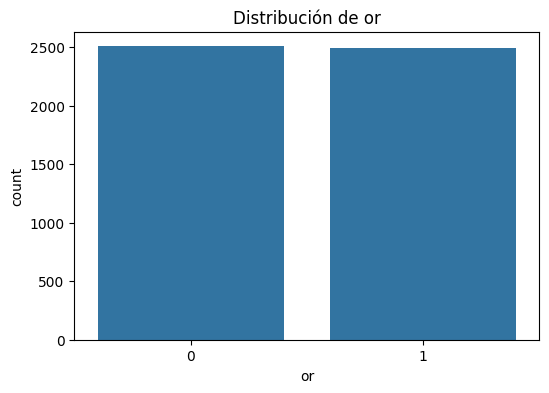

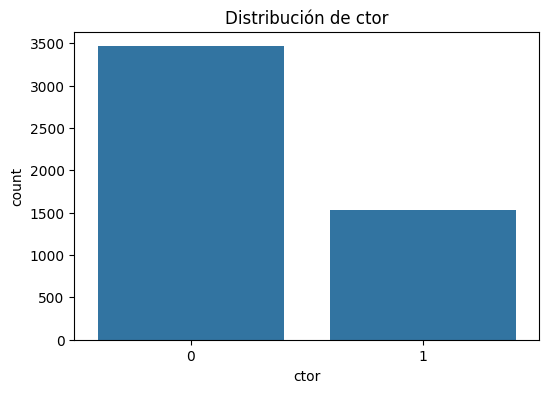

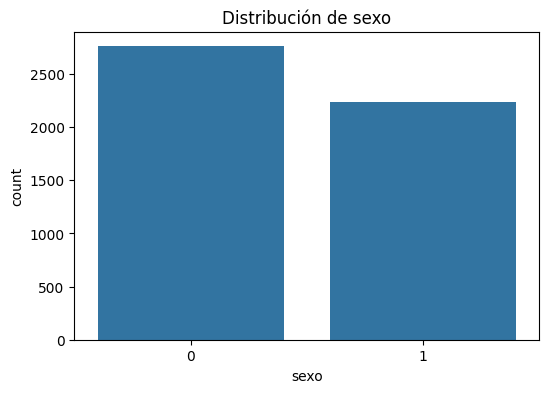

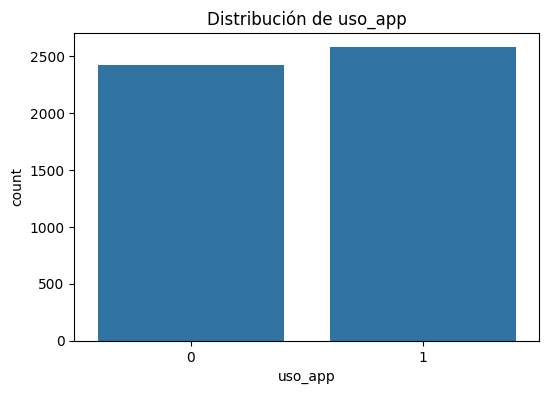

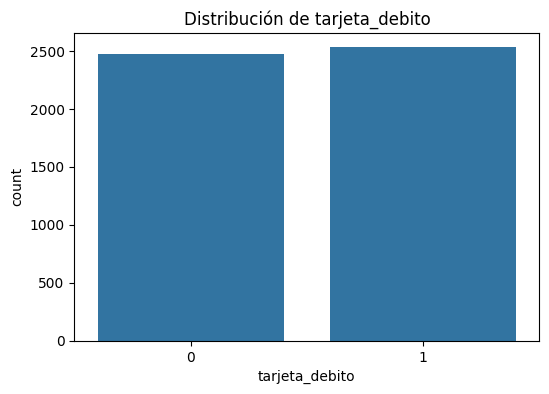

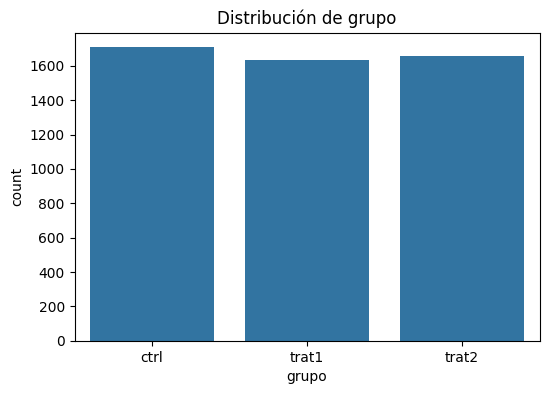

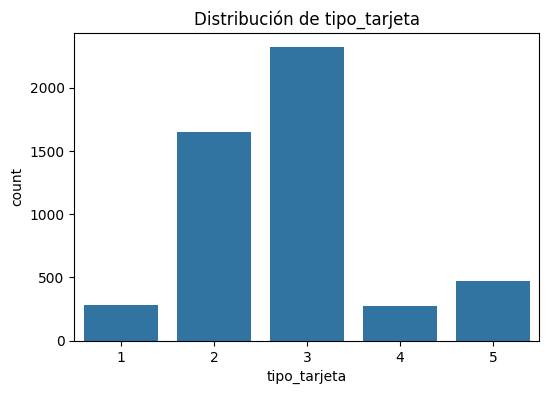

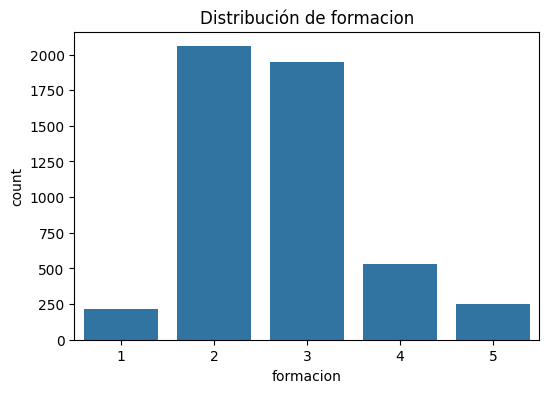

In [37]:
# Análisis de variables categóricas (grupo, sexo, uso_app, tarjeta_debito, tipo_tarjeta)
print("\n--- Análisis de Variables Binarias ---")
for var in ['or', 'ctor', 'sexo', 'uso_app', 'tarjeta_debito','grupo', 'tipo_tarjeta', 'formacion']:
    plt.figure(figsize=(6, 4))
    # Contablet es mejor para contar frecuencias en variables binarias/categóricas
    sns.countplot(x=df[var])
    plt.title(f'Distribución de {var}')
    plt.show()

##### Relación entre variables

In [69]:
#Creación de función para el open rate
def open_rate(dataframe, column_names):
    # Agrupa por las columnas indicadas y cuenta los usuarios únicos que abrieron
    opened = dataframe[dataframe['or'] == 1].groupby(column_names)['iid'].nunique()
    
    # Agrupa por las columnas indicadas y cuenta el total de usuarios únicos
    total_users = dataframe.groupby(column_names)['iid'].nunique()
        
    # Calcula la tasa de apertura
    open_rate = round(opened / total_users * 100, 1)
    
    return open_rate

#Creación de función para el click to open rate
def ctor_rate(dataframe, column_names):
    # Agrupa por las columnas indicadas y cuenta los usuarios únicos que abrieron
    clicked = dataframe[(dataframe['or'] == 1) & (dataframe['ctor'] == 1)].groupby(column_names)['iid'].nunique()
    
    # Agrupa por las columnas indicadas y cuenta el total de usuarios únicos
    opened = dataframe[dataframe['or'] == 1].groupby(column_names)['iid'].nunique()
        
    # Calcula la tasa de apertura
    ctor_rate = round(clicked / opened * 100, 1)
    
    return ctor_rate

In [70]:
# Exploración del open rate
print("\n--- Open Rate por Grupo ---") 
resultado_open = open_rate(df, ['grupo', 'sexo'])
open_rate_df = pd.DataFrame(resultado_open)
print(open_rate_df)

# Exploración del click to open rate
print("\n--- Click to Open Rate por Grupo ---") 
resultado_ctor = ctor_rate(df, ['grupo', 'sexo'])
ctor_rate_df = pd.DataFrame(resultado_ctor)
print(ctor_rate_df)


--- Open Rate por Grupo ---
             iid
grupo sexo      
ctrl  0     29.0
      1     28.6
trat1 0     61.9
      1     59.6
trat2 0     68.1
      1     47.3

--- Click to Open Rate por Grupo ---
             iid
grupo sexo      
ctrl  0     29.5
      1     31.1
trat1 0     59.6
      1     56.5
trat2 0     85.2
      1     67.8
